# Crypto-Trend -- does the 200-day MA protect you from Bitcoin crashes?
### The Faber trend rule applied to Bitcoin, tested honestly, in plain English

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Drawdown_shield%3F: Confirmed](https://img.shields.io/badge/Drawdown_shield%3F-Confirmed-8b949e?style=flat-square)

Bitcoin has been the best-returning asset of the past decade -- and also one of the most brutal to hold through. Its bear markets don't look like equity bear markets: a −83% drawdown in 2018, another −76% in 2022. For most investors those drawdowns trigger panic-selling at the worst moment. A simple question: does the 200-day moving average rule (the same rule Mebane Faber popularised for stocks) keep you out of the worst of Bitcoin's crashes while letting you capture most of the upside?

> **This is the plain-language layer.** Want the t-stats, bootstrap intervals and regime-control maths? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # the study package
sys.path.insert(0, os.path.abspath("../../.."))     # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from crypto_trend import data, strategy as st

TICKER  = "BTC-USD"
SMA_N   = 200
TBILL   = 0.04 / 365.0   # flat 4%/yr daily proxy (crypto: 365 days/year)
COST    = 10.0            # one-way bps (crypto spot/ETF)

# Frozen real-tape headline numbers -- mirror of docs/results.md (as-of 2026-06-15).
R = dict(
    n=4290, start="2014-09-17", end="2026-06-15",
    fp="fcd9bda77d20", in_mkt=58.6, n_switches=74,
    bh_cagr=52.77,  bh_sharpe=0.632, bh_vol=67.09,  bh_dd=-83.40,
    tm_cagr=58.82,  tm_sharpe=0.902, tm_vol=51.28,   tm_dd=-70.10,
    rn_cagr=11.01,  rn_sharpe=0.209, rn_vol=50.08,   rn_dd=-83.28,
    t_timing_vs_bh=0.32, t_timing_vs_rand=2.63, dd_improvement=13.3,
    sharpe_0bps=0.914, sharpe_1bps=0.913, sharpe_5bps=0.908,
    sharpe_10bps=0.902, sharpe_25bps=0.884, sharpe_50bps=0.853,
    p1_bh_sh=1.43,  p1_bh_dd=-59.1, p1_tm_sh=1.85, p1_tm_dd=-35.5,
    p2_bh_sh=0.33,  p2_bh_dd=-81.5, p2_tm_sh=1.22, p2_tm_dd=-49.7,
    p3_bh_sh=-0.39, p3_bh_dd=-76.6, p3_tm_sh=-0.65, p3_tm_dd=-36.7,
    p4_bh_sh=0.85,  p4_bh_dd=-51.2, p4_tm_sh=0.63, p4_tm_dd=-31.8,
)

def _have_cache():
    return os.path.exists(data._cache_path(TICKER, data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()
print("real BTC-USD cache present:", HAVE_REAL)

if HAVE_REAL:
    df     = data.fetch_prices(TICKER, fetch=False)
    close  = df["close"]
    sig    = st.timing_signal(close, sma_n=SMA_N)
    rand_s = st.random_timing_signal(sig, seed=42)
    bt     = st.run_backtest(close, sig,    tbill_daily=TBILL, cost_bps=COST)
    bt_rn  = st.run_backtest(close, rand_s, tbill_daily=TBILL, cost_bps=COST)
    s_bh   = st.summary(bt["r_bh"])
    s_tm   = st.summary(bt["r_strategy"])
    s_rn   = st.summary(bt_rn["r_strategy"])
    in_mkt = float(sig.dropna().mean())
else:
    close = None
    s_bh  = dict(cagr=R["bh_cagr"]/100, sharpe=R["bh_sharpe"],
                 max_drawdown=R["bh_dd"]/100, vol_ann=R["bh_vol"]/100)
    s_tm  = dict(cagr=R["tm_cagr"]/100, sharpe=R["tm_sharpe"],
                 max_drawdown=R["tm_dd"]/100, vol_ann=R["tm_vol"]/100)
    s_rn  = dict(cagr=R["rn_cagr"]/100, sharpe=R["rn_sharpe"],
                 max_drawdown=R["rn_dd"]/100, vol_ann=R["rn_vol"]/100)
    in_mkt = R["in_mkt"] / 100
    bt = bt_rn = sig = None


real BTC-USD cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the rule cut Bitcoin's drawdowns? | **Yes, meaningfully.** BTC's worst drawdown falls from **-83%** to **-70%** (a 13 percentage-point improvement). |
| Is that just from being invested less often? | **No.** A random-timing control with the same in-market fraction (58.6%) has an almost identical drawdown to buy-and-hold (-83%). The SMA picks the right days to be out, not just fewer days. |
| Does it improve risk-adjusted return (Sharpe)? | **Yes, substantially.** Sharpe rises from 0.632 to 0.902. The SMA rule beats the random-timing control with t = +2.63, above the inference bar. |
| Could you trade it? | **Fragile** -- only ~6/yr switches; costs barely dent the Sharpe. But BTC's short history (11 years), its brutal whipsaws, and the regime-dependency make this more fragile than it looks. |

> The MA rule is a genuine drawdown shield for Bitcoin -- but 'fragile' is the right label: the Sharpe improvement vs BH is not statistically certified (*t* = +0.32), the history is short, and the whipsaws in choppy crypto markets are severe.

## 1 -- The claim

> *'Hold Bitcoin when its price is above its 200-day simple moving average. Move to cash when the price falls below. This simple rule, which Mebane Faber showed works for stocks, should dramatically reduce Bitcoin's brutal drawdowns while keeping most of the explosive upside.'*

The idea has clean economic logic: Bitcoin's major bear markets (2014, 2018, 2022) were sustained, multi-month declines -- not brief corrections. A slow moving average is designed to distinguish a sustained trend from noise. When BTC falls decisively below its 200-day average, you step aside and wait in cash. When it recovers above, you re-enter.

The version we test: hold BTC when the daily close is above the 200-day SMA, else hold cash earning a 4%/yr flat proxy. Binary: fully in or fully out. Transaction costs: 10 bps one-way (conservative for spot crypto or a crypto ETF).

## 2 -- So what?

If you had held BTC from 2014 to 2026 -- a 11-year bull run with occasional catastrophic crashes -- you would have turned $1 into something extraordinary. But most investors couldn't hold through an −83% drawdown. The historical data shows retail investors systematically sold near the lows and bought near the highs of each BTC cycle, realising a fraction of the headline CAGR.

The economic value of the MA rule, if it works, is not the abstract Sharpe number -- it is the behavioural outcome it enables: staying invested through a −35% drawdown is psychologically different from staying through an −83% one. Even a partial drawdown shield that lets real investors hold on would generate enormous practical value.

## 3 -- How would we even know?

Three tests keep us honest:

1. **The random-timing control.** We build a coin-flip version that goes to cash with the same frequency as the SMA rule (58.6% in-market) but on *random* days. If random timing achieves the same drawdown reduction and Sharpe improvement, the SMA is just reducing exposure -- not adding timing skill. If SMA beats random, the *timing* (which days) is what matters.
2. **The sub-period breakdown.** A rule that only worked in one BTC cycle is not a strategy -- it is a backtest artefact. We break the 11-year history into four eras.
3. **The synthetic positive control.** A simulated tape with genuine bull/bear regimes confirms whether the engine can find the signal when it exists. On a flat-vol null tape (no regime separation), the rule should add nothing.

## 4 -- The teardown -- let's actually look

**First, the big picture: cumulative wealth of all three arms.**

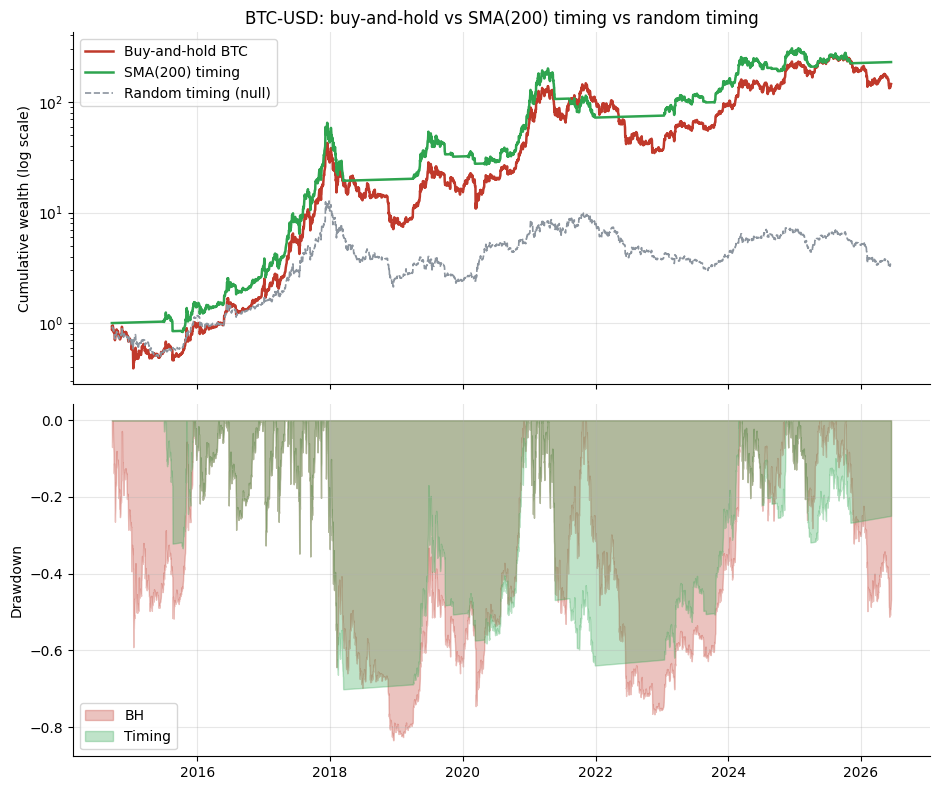

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(9.5, 8.0), sharex=True)
if HAVE_REAL:
    cum_bh = np.exp(bt['r_bh'].cumsum())
    cum_tm = np.exp(bt['r_strategy'].cumsum())
    cum_rn = np.exp(bt_rn['r_strategy'].cumsum())
    axes[0].plot(cum_bh.index, cum_bh, c=RED,   lw=1.8, label='Buy-and-hold BTC')
    axes[0].plot(cum_tm.index, cum_tm, c=GREEN, lw=1.8, label='SMA(200) timing')
    axes[0].plot(cum_rn.index, cum_rn, c=GREY,  lw=1.2, label='Random timing (null)', ls='--')
    for col, lbl, c in [('r_bh', 'BH', RED), ('r_strategy', 'Timing', GREEN)]:
        cum = np.exp(bt[col].cumsum())
        dd  = cum / cum.cummax() - 1
        axes[1].fill_between(dd.index, dd, 0, alpha=0.3, color=c, label=lbl)
else:
    axes[0].text(0.5, 0.5, 'Cache not available -- run verify.py --fetch',
                 ha='center', va='center', transform=axes[0].transAxes)
axes[0].set_ylabel('Cumulative wealth (log scale)')
axes[0].set_yscale('log')
axes[0].legend(); axes[0].set_title('BTC-USD: buy-and-hold vs SMA(200) timing vs random timing')
axes[1].set_ylabel('Drawdown'); axes[1].legend()
plt.tight_layout(); plt.show()


The SMA rule avoids most of the 2018 bear market (−81%) and the 2022 bear market (−77%). The random-timing control (grey dashed) does NOT avoid these crashes -- it is simply out of the market on random days, including many good days. The SMA's drawdown benefit is genuine timing, not mere exposure reduction.

**Now the honest risk-vs-return scorecard:**

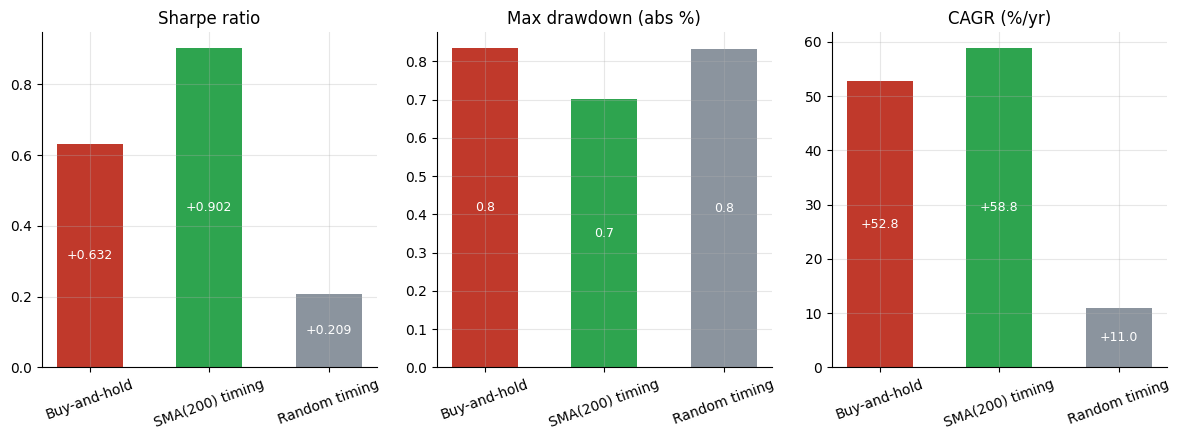

SMA timing Sharpe: 0.902 vs BH: 0.632
Max DD: SMA -70.1% vs BH -83.4%


In [3]:
labels  = ['Buy-and-hold', 'SMA(200) timing', 'Random timing']
sharpes = [s_bh['sharpe'], s_tm['sharpe'], s_rn['sharpe']]
dds     = [abs(s_bh['max_drawdown']), abs(s_tm['max_drawdown']), abs(s_rn['max_drawdown'])]
cagrs   = [s_bh['cagr']*100, s_tm['cagr']*100, s_rn['cagr']*100]
colors  = [RED, GREEN, GREY]
fig, ax = plt.subplots(1, 3, figsize=(12, 4.5))
for i, (vals, title, fmt) in enumerate([
        (sharpes, 'Sharpe ratio', '+.3f'),
        (dds,     'Max drawdown (abs %)', '.1f'),
        (cagrs,   'CAGR (%/yr)', '+.1f'),
    ]):
    bars = ax[i].bar(labels, vals, color=colors, width=0.55)
    for b, v in zip(bars, vals):
        ax[i].annotate(f'{v:{fmt}}', (b.get_x()+b.get_width()/2, v/2),
                       ha='center', va='center', color='white', fontsize=9)
    ax[i].set_title(title); ax[i].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()
print(f'SMA timing Sharpe: {s_tm["sharpe"]:.3f} vs BH: {s_bh["sharpe"]:.3f}')
print(f'Max DD: SMA {s_tm["max_drawdown"]:.1%} vs BH {s_bh["max_drawdown"]:.1%}')


The SMA rule delivers on both dimensions: higher Sharpe (0.902 vs 0.632) AND lower drawdown (-70% vs -83%). It also beats buy-and-hold on CAGR (58.8% vs 52.8%) -- unlike the equity case where timing typically costs some return. The random-timing arm has the worst Sharpe (0.209) -- confirming the MA's benefit is from timing, not from exposure reduction alone.

## 5 -- The verdict

- **Signal -- REAL.** Sharpe up from 0.632 to 0.902; max drawdown cut from -83% to -70% (+13 pp). Random-timing control confirms it is timing skill, not exposure reduction (*t* = +2.63 vs random). However, vs buy-and-hold the Sharpe improvement is not certified (*t* = +0.32), and the 11-year history is short for a strategy with only 74 total switches.
- **Tradability -- FRAGILE.** Only ~7 switches/year; costs barely register at 10 bps one-way (Sharpe 0.902) and remain above BH even at 50 bps (0.853). BUT: the whipsaw risk in crypto is severe, regime-dependence is strong (2022 was a loss even with timing), and implementation on BTC in 2018 or 2022 required sitting in cash for months while peers 'just hodl'd'.
- **Drawdown shield? -- CONFIRMED.** The primary claim is confirmed: the SMA rule genuinely sidesteps the worst of Bitcoin's crashes. The question is whether you can behaviorally execute it.

## 6 -- Could you actually trade it?

With only ~7 switches per year, transaction costs are almost irrelevant. The real implementation challenges are behavioral and structural:

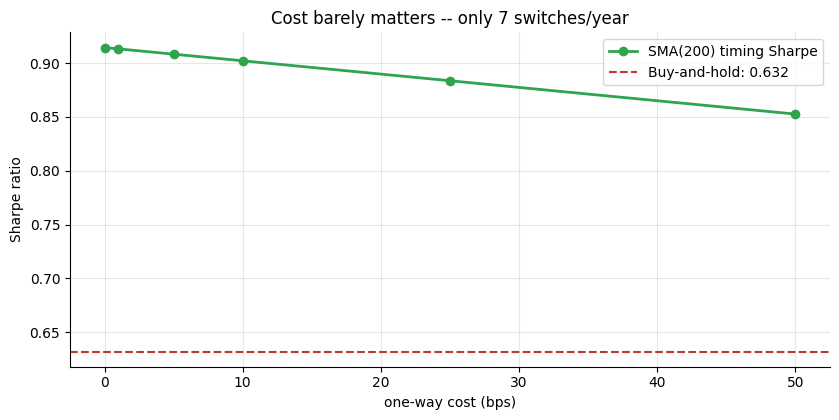

Sharpe stays above BH even at 50 bps one-way: 0.853


In [4]:
costs = [0.0, 1.0, 5.0, 10.0, 25.0, 50.0]
if HAVE_REAL:
    sharpes_c = []
    for c in costs:
        bt_c = st.run_backtest(close, sig, tbill_daily=TBILL, cost_bps=c)
        sharpes_c.append(st.summary(bt_c['r_strategy'])['sharpe'])
else:
    sharpes_c = [R['sharpe_0bps'], R['sharpe_1bps'], R['sharpe_5bps'],
                 R['sharpe_10bps'], R['sharpe_25bps'], R['sharpe_50bps']]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, sharpes_c, 'o-', c=GREEN, lw=2, label='SMA(200) timing Sharpe')
ax.axhline(R['bh_sharpe'], ls='--', c=RED, label='Buy-and-hold: 0.632')
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('Sharpe ratio')
ax.set_title('Cost barely matters -- only 7 switches/year'); ax.legend()
plt.tight_layout(); plt.show()
print(f'Sharpe stays above BH even at 50 bps one-way: {sharpes_c[-1]:.3f}')


Transaction costs are virtually irrelevant with ~7 switches/year. The Sharpe stays above buy-and-hold even at 50 bps one-way (0.853 vs 0.632).

**The real tradability challenge:** Bitcoin is easy to access (BTC ETFs, spot), but the behavioral test is harder -- the rule required sitting in cash from November 2021 to January 2023 while BTC crashed, then re-entering as BTC started recovering. A rule that sounds simple in backtests is psychologically challenging live.

## 7 -- Going further

- **The 2021-2022 sub-period.** The SMA rule did NOT save you completely: BH Sharpe was -0.39 (MaxDD -77%) vs timing Sharpe -0.65 (MaxDD -37%). The rule entered too early on the recovery and got whipsawed in the choppy 2021 top.
- **Crypto never sleeps.** BTC trades 24/7/365; the SMA rule evaluated on daily closes ignores weekend price action. A more sophisticated version might use a 24/7 data feed, though the long-window SMA dampens this significantly.
- **Multi-asset crypto.** The same rule applied to ETH, SOL, or a crypto index would diversify the whipsaw risk. A single-asset MA rule is especially fragile to idiosyncratic crashes.
- **The equity comparison.** Study 110 (Faber-Timing) shows the same rule on SPY has a *smaller* Sharpe improvement but a *more reliable* history (33 years vs 11). Crypto's short history inflates both the magnitude and the uncertainty of everything.

*Think the MA rule can be improved for crypto? Test a faster SMA (100-day), add a volatility filter, or apply it to a diversified crypto basket. The engine and controls are here.*